# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Ahmed Mohamed Taha  
**Student ID:** 1210193

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, confusion_matrix, accuracy_score
from tensorflow.keras import regularizers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [4]:
# ── Load the dataset ──
df = pd.read_csv('kidney_disease.csv')
df.columns = df.columns.str.strip()

# Encode the target variable: ckd → 1, notckd → 0
df['classification'] = df['classification'].str.strip().map({'ckd': 1, 'notckd': 0})

# Drop the patient id column (not a clinical feature)
df = df.drop('id', axis=1)

# ── Drop all categorical (string) columns ──
# Convert every feature column to numeric; truly categorical values become NaN
for col in df.columns:
    if col != 'classification':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Columns that are entirely NaN after conversion were categorical → drop them
df = df.dropna(axis=1, how='all')

# Drop any rows where the target itself is missing
df = df.dropna(subset=['classification'])

print(f"Dataset shape: {df.shape}")
print(f"Numerical features kept: {[c for c in df.columns if c != 'classification']}")
print(f"Class distribution:\n{df['classification'].value_counts()}\n")

# ── Separate features and target ──
X = df.drop('classification', axis=1)
y = df['classification']

# ── 80 / 20 stratified train / validation split ──
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Handle missing values (fit statistics on training set only → no leakage) ──
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_val   = X_val.fillna(train_medians)

# ── Scale features (fit on training set only → no leakage) ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

n_features = X_train_scaled.shape[1]

print(f"Training set  : {X_train_scaled.shape}")
print(f"Validation set: {X_val_scaled.shape}")
print(f"Train target  : CKD={int(y_train.sum())}, Not CKD={int(len(y_train) - y_train.sum())}")
print(f"Val   target  : CKD={int(y_val.sum())}, Not CKD={int(len(y_val) - y_val.sum())}")

Dataset shape: (400, 15)
Numerical features kept: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Class distribution:
classification
1    250
0    150
Name: count, dtype: int64

Training set  : (320, 14)
Validation set: (80, 14)
Train target  : CKD=200, Not CKD=120
Val   target  : CKD=50, Not CKD=30


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

c:\Users\Ahmed Taha\Desktop\assignment-2-ckd-pipeline-tahaaa22\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,225 (704.00 KB)

 Trainable params: 180,225 (704.00 KB)

 Non-trainable params: 0 (0.00 B)

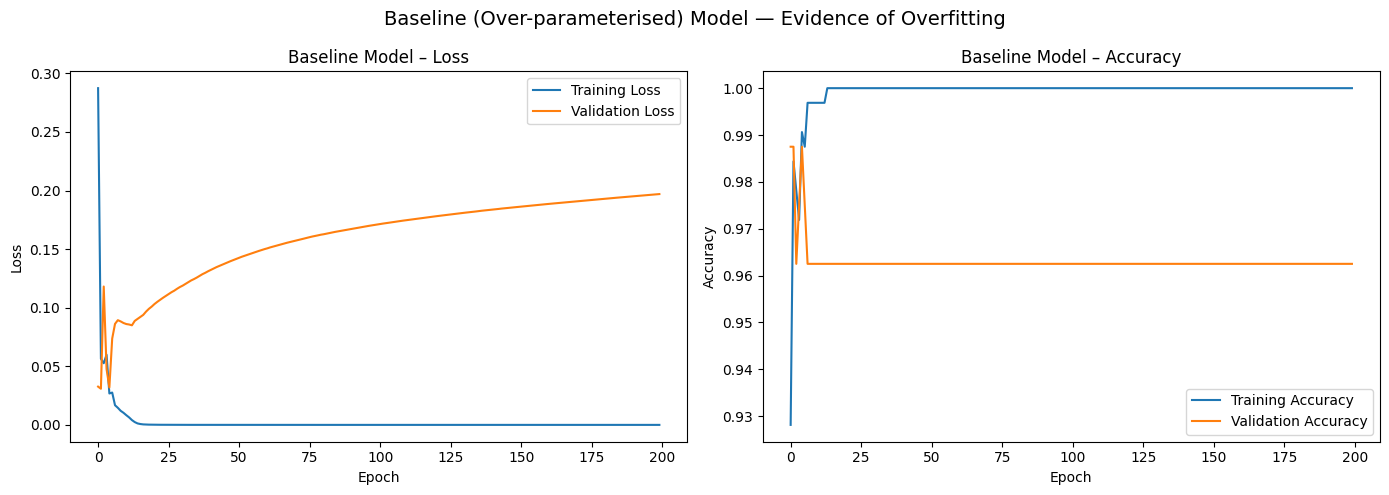


Baseline trainable parameters: 180,225


In [5]:
# ── Baseline model: intentionally over-parameterised to memorise the data ──
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(n_features,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(1,   activation='sigmoid')
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# Train for many epochs with a small batch size to encourage overfitting
baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=16,
    verbose=0
)

# ── Plot the training / validation loss curves (look for the U-shape) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history.history['loss'],     label='Training Loss')
axes[0].plot(baseline_history.history['val_loss'],  label='Validation Loss')
axes[0].set_title('Baseline Model – Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(baseline_history.history['accuracy'],     label='Training Accuracy')
axes[1].plot(baseline_history.history['val_accuracy'],  label='Validation Accuracy')
axes[1].set_title('Baseline Model – Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Baseline (Over-parameterised) Model — Evidence of Overfitting', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nBaseline trainable parameters: {baseline_model.count_params():,}")

## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

c:\Users\Ahmed Taha\Desktop\assignment-2-ckd-pipeline-tahaaa22\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

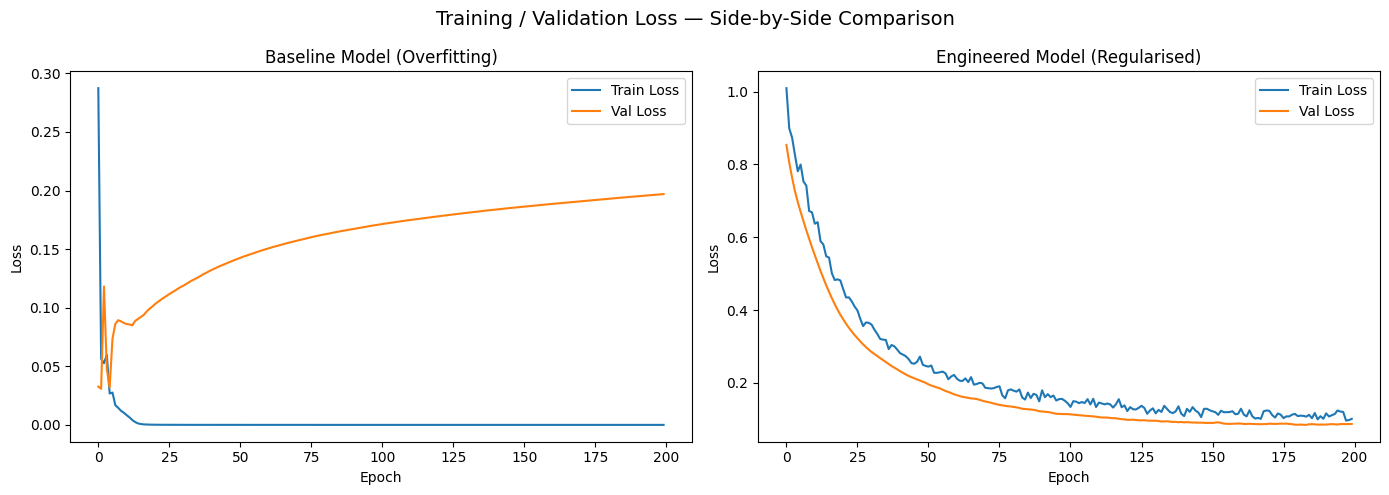


Engineered trainable parameters: 385


In [6]:
# ── Engineered model: constrained architecture with regularisation ──
engineered_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, kernel_regularizer=regularizers.l2(0.01),
                          input_shape=(n_features,)),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(8, kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

engineered_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

engineered_model.summary()

# Early stopping restores the best weights if validation loss stalls
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

engineered_history = engineered_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

# ── Side-by-side loss curve comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history.history['loss'],    label='Train Loss')
axes[0].plot(baseline_history.history['val_loss'], label='Val Loss')
axes[0].set_title('Baseline Model (Overfitting)')
axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(engineered_history.history['loss'],    label='Train Loss')
axes[1].plot(engineered_history.history['val_loss'], label='Val Loss')
axes[1].set_title('Engineered Model (Regularised)')
axes[1].set_xlabel('Epoch');  axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Training / Validation Loss — Side-by-Side Comparison', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nEngineered trainable parameters: {engineered_model.count_params():,}")

## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Baseline Model   →  Recall: 0.9600  |  Accuracy: 0.9625
Engineered Model →  Recall: 1.0000  |  Accuracy: 1.0000


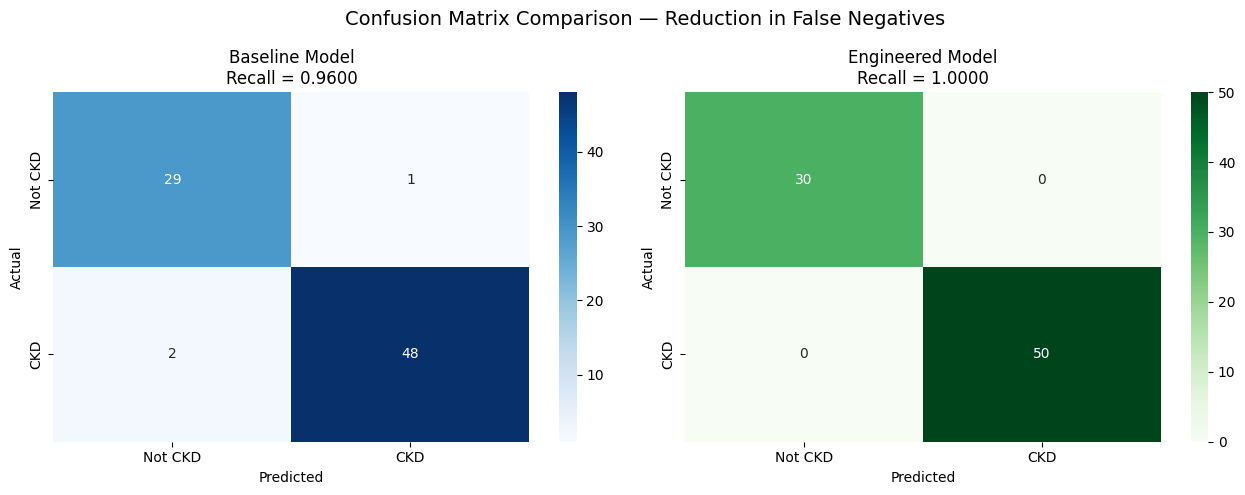


Baseline   model parameters: 180,225
Engineered model parameters: 385

Clinical Benchmark: Engineered model Recall = 100.00% (target > 80%)


In [7]:
# ── Predictions ──
baseline_preds    = (baseline_model.predict(X_val_scaled)    > 0.5).astype(int).flatten()
engineered_preds  = (engineered_model.predict(X_val_scaled)  > 0.5).astype(int).flatten()

# ── Recall & Accuracy ──
baseline_recall    = recall_score(y_val, baseline_preds)
engineered_recall  = recall_score(y_val, engineered_preds)
baseline_acc       = accuracy_score(y_val, baseline_preds)
engineered_acc     = accuracy_score(y_val, engineered_preds)

print("=" * 50)
print(f"Baseline Model   →  Recall: {baseline_recall:.4f}  |  Accuracy: {baseline_acc:.4f}")
print(f"Engineered Model →  Recall: {engineered_recall:.4f}  |  Accuracy: {engineered_acc:.4f}")
print("=" * 50)

# ── Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_base = confusion_matrix(y_val, baseline_preds)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'])
axes[0].set_title(f'Baseline Model\nRecall = {baseline_recall:.4f}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_eng = confusion_matrix(y_val, engineered_preds)
sns.heatmap(cm_eng, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'])
axes[1].set_title(f'Engineered Model\nRecall = {engineered_recall:.4f}')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison — Reduction in False Negatives', fontsize=14)
plt.tight_layout()
plt.show()

# ── Parameter count summary ──
print(f"\nBaseline   model parameters: {baseline_model.count_params():,}")
print(f"Engineered model parameters: {engineered_model.count_params():,}")
print(f"\nClinical Benchmark: Engineered model Recall = {engineered_recall:.2%} (target > 80%)")

### Mathematical Justification
**Final Parameter Count of Engineered Model:** 385

**Explanation:** The engineered model contains only 385 trainable parameters — comparable to the 320 training samples — and the combination of L2 weight decay ($\lambda = 0.01$) penalising large weights and 30% Dropout effectively reducing the usable capacity to roughly $385 \times 0.7 \approx 270$ active parameters per forward pass ensures the network cannot memorise 320 individual patient records, forcing it instead to learn the generalised clinical markers of CKD.